In [1]:
# Colab setup -- installs SoftMobility when running on Google Colab.
# Safe to run locally: it does nothing outside Colab.
try:
    import google.colab  # noqa: F401
    %pip install -q git+https://github.com/C0PEP0D/SoftMobility.git
except ImportError:
    pass

# Example 08. Soft surfer in Taylor–Green vortices

## Background

**Gyrotaxis.** Many bottom-heavy microswimmers (e.g. the alga *Chlamydomonas*) reorient passively in a shear flow: gravity pulls the heavy end down while viscous torques tend to rotate the body along the local vorticity. For small vorticity, the competition between the two torques sets a stable swimming direction that depends on the local flow: a mechanism called *gyrotaxis*. In a vortical flow such as Taylor–Green, gyrotaxis biases the swimmers toward downwelling regions: they spend more time in the downward-flow parts of the vortex than in the upward ones (a form of preferential sampling). As a result, their effective vertical speed $V_\mathrm{eff}$ is smaller than their swimming speed $V_\mathrm{swim}$ in still fluid.

**Question.** Can a *soft* swimmer invert this bias and *surf* the flow upward, achieving $V_\mathrm{eff} > V_\mathrm{swim}$?

**Three swimmers are compared in this notebook.** All three have the same swim speed $V_\mathrm{swim}=1$ and are released from the same 15 initial positions, integrated for $T = 4\pi/\omega_\mathrm{max}$ in a Taylor–Green flow of maximum angular velocity $\omega_\mathrm{max}=1$:
* **Rigid:** an asymmetric dumbbell with a light upper sphere of radius $a_0$ and a heavy lower sphere of radius $a_1<a_0$, rigidly joined. Its orientation obeys the Pedley–Kessler gyrotactic balance and it serves as the baseline (we expect $V_\mathrm{eff} < V_\mathrm{swim}$).
* **Soft:** same dumbbell geometry, but the two spheres are coupled by a torsional spring of stiffness $k$ that lets the active-force direction tilt away from the bottom-heavy axis. We optimize the two design parameters $(a_1/a_0,\;\bar k = k/(\mu\,\omega_\mathrm{max}\,a_0^3))$ with `sm.FlowBodyOptimizer` to maximize $V_\mathrm{eff}$.
* **Surfer:** a reference strategy (not a physical body) whose swimming direction follows the *surfing strategy* of Monthiller et al. (2022): the heading aligns with $\mathbf{e}_3\cdot\exp(\tau\,\nabla\mathbf{u})$, the image of the vertical $\mathbf{e}_3$ pushed through the local flow gradient over a lookahead time $\tau$. We optimize the single parameter $\tau$.

Throughout, $V_\mathrm{eff}$ is the mean vertical drift of the swimmer averaged over the 15 initial conditions and divided by the total simulation time `FINAL_TIME`.

### Imports


In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
from jax.scipy.linalg import expm

import softmobility as sm
from softmobility.classes import figstyle

jax.config.update("jax_enable_x64", True)
figstyle.apply()
np.set_printoptions(precision=3, linewidth=100, suppress=True, sign=" ")

FIGDIR = "figures"


## 1. Defining the soft and rigid bodies


### The Pedley–Kessler model

For a rigid bottom-heavy swimmer with swimming direction $\mathbf{p}=\mathbf{E}_3$, the gyrotactic balance between viscous torque (from the local vorticity $\boldsymbol{\omega}_0^\infty$) and gravitational restoring torque is summarized by the Pedley–Kessler equation,
$$
\dot{\mathbf{p}} = 
    \boldsymbol{\omega}_0^\infty \times \mathbf{p} + 
    + \beta\left(\mathbf{E}_0^\infty\cdot\mathbf{p} - (\mathbf{p}\cdot\mathbf{E}_0^\infty\cdot\mathbf{p})\mathbf{p}\right) +
    \frac{1}{2\,\tau_\mathrm{align}}\Bigl(\mathbf{e}_3 - (\mathbf{e}_3\cdot\mathbf{p})\,\mathbf{p}\Bigr).
$$
The first term tumbles the swimmer with the flow; the second is the coupling with the strain; the thrid restores its direction toward the vertical $\mathbf{e}_3$ on a timescale $\tau_\mathrm{align}$ set by the bottom-heaviness. Here we do **not** integrate this equation directly: it emerges from the bead-spring soft-body dynamics once gravity is applied to two spheres at different positions. In other words, the "rigid body" below is the natural rigid limit of our soft swimmer; its rotational dynamics reproduce Pedley–Kessler with $\tau_\mathrm{align}$ set by the body's rotational mobility.

The YAML descriptions below define the two bodies:
* `mybody` — the soft swimmer: one rolling degree of freedom $\phi$, two design parameters (`spring_k` and `radius`).
* `myrigidbody` — the rigid counterpart: no degrees of freedom, one design parameter (`radius`).

The scaling factors `_spr_=50` and `_rad_=1` map the optimizer's $[0,1]$ search space onto the physical spring stiffness and sphere-radius ratio.

In [3]:
yaml_data = """
# Variable Prefixes (Optional)
dof_names:
  - phi
design_names:
  - spring_k
  - radius
input_names:
  - gravity
  - active_force

# Default Values (Optional)
# Note: the variables with underscores are used to set the range of the design variables,
# such that spring_k and radius are optimized in the range [0, 1].
defaults:
  spring_k: .5
  radius: .33
  _spr_: 50
  _rad_: 1

# Spheres (Mandatory)
spheres:
  - # Sphere 0 #################
    radius: 1
    position: [0, 0, 1]
    orientation: [phi, 0, 0]
    force: [-gravity0, -gravity1, -gravity2]
    torque: [-_spr_ * spring_k * phi, 0, 0]

  - # Sphere 1 #################
    radius: _rad_ * radius
    position: [0, 0, -radius]
    orientation: [-phi/_rad_/radius, 0, 0]
    force: [gravity0,
             gravity1 + active_force * sin(phi/_rad_/radius),
             gravity2 + active_force * cos(phi/_rad_/radius)]
    torque: [_spr_ * spring_k * phi, 0, 0]
"""

yaml_data_rigid = """
# Variable Prefixes (Optional)
design_names:
  - radius
input_names:
  - gravity
  - active_force

# Default Values (Optional)
defaults:
  radius: .5
  _rad_: 1

# Spheres (Mandatory)
spheres:
  - # Sphere 0 #################
    radius: 1
    position: [0, 0, 1]
    orientation: [0, 0, 0]
    force: [-gravity0, -gravity1, -gravity2]
    torque: [0, 0, 0]

  - # Sphere 1 #################
    radius: _rad_ * radius
    position: [0, 0, -radius]
    orientation: [0, 0, 0]
    force: [gravity0, gravity1, gravity2 + active_force]
    torque: [0, 0, 0]
"""

In [ ]:
mybody = sm.SoftBody(yaml_data, verbose=True)
myrigidbody = sm.SoftBody(yaml_data_rigid, verbose=False)

  Found variables: phi, radius, spring_k, gravity0, gravity1, gravity2, active_force
  3D field inputs:  ['gravity']
  Scalar inputs:    ['active_force']
    Sphere 0
      Radius: 1
      Position: ['0', '0', '1']
      Orientation: ['phi', '0', '0']
      Force: ['-gravity0', '-gravity1', '-gravity2']
      Torque: ['-50*phi*spring_k', '0', '0']
    Sphere 1
      Radius: radius
      Position: ['0', '0', '-radius']
      Orientation: ['-phi/radius', '0', '0']
      Force: ['gravity0', 'active_force*sin(phi/radius) + gravity1', 'active_force*cos(phi/radius) + gravity2']
      Torque: ['50*phi*spring_k', '0', '0']


## 2. Flow, gravity, and active force


In [ ]:
# Calibrate active force so the rigid body swims at unit speed in still fluid.
tensors = myrigidbody.compute_fast_tensors(dofs=jnp.zeros(myrigidbody.Ndof))
FORCE_INTENSITY = 1.0 / tensors.M_H[2, -1]

FLOW = sm.taylor_green_flow(omega=1)  # max angular velocity omega_max = 1, matching the manuscript
GRAVITY = sm.gravity_field(g=50.0)
FORCE = sm.constant_scalar(value=FORCE_INTENSITY)

In [6]:
FINAL_TIME = 4 * jnp.pi
DT = 0.1
N_DT = int(FINAL_TIME / DT)
N_TRAJECTORIES = 15

Y_INIT_POSITIONS = np.linspace(
    np.pi / N_TRAJECTORIES / 2, 2 * np.pi, N_TRAJECTORIES, endpoint=False
)

In [7]:
ROLLOUT = sm.FlowBodyRollout(
    soft_body=mybody,
    flow=FLOW,
    input_map={"gravity": GRAVITY, "active_force": FORCE},
)

## 3. Optimizing the soft body


In [8]:
def my_objective(rollout, design):
    tensors = mybody.compute_tensors(design=design)
    force_norm = 1.0 / tensors.M_H[2, 3]
    FORCE.update_params(force_norm)

    velocities = jnp.stack([
        rollout.rollout(
            dt=DT,
            n_steps=N_DT,
            init_position=[0, x_init, 0],
            design=design,
        )[0][-1, 2] / FINAL_TIME
        for x_init in Y_INIT_POSITIONS
    ])
    return jnp.mean(velocities)


In [ ]:
myoptimizer = sm.FlowBodyOptimizer(ROLLOUT, my_objective, optimizer=optax.adam(0.001))

optimal_design = myoptimizer.run(
    init_design=0.5 * jnp.ones(mybody.Ndesign),
    n_steps=1000,
    print_every=100,
    clip_min=0.01,
    clip_max=1.0,
    grad_clip=0.1,
    maximize=True,
)


step    0  objective=0.8909  |grad|=0.1000  design0=0.50  design1=0.50
step  100  objective=1.0084  |grad|=0.1000  design0=0.41  design1=0.39
step  200  objective=1.1482  |grad|=0.1000  design0=0.33  design1=0.28
step  300  objective=1.1909  |grad|=0.0309  design0=0.23  design1=0.32
step  400  objective=1.1923  |grad|=0.0287  design0=0.19  design1=0.35
step  500  objective=1.1930  |grad|=0.0011  design0=0.17  design1=0.36
step  600  objective=1.1930  |grad|=0.0000  design0=0.17  design1=0.36
step  700  objective=1.1930  |grad|=0.0000  design0=0.17  design1=0.36
step  800  objective=1.1930  |grad|=0.0000  design0=0.17  design1=0.36
step  900  objective=1.1930  |grad|=0.0000  design0=0.17  design1=0.36
step  999  objective=1.1930  |grad|=0.0000  design0=0.17  design1=0.36


In [ ]:
print("Design parameters:", mybody.design_variables)
print(
    "Optimal design:",                      # multiplied by the scaling factors to get 
    optimal_design * np.array([1, 50]))     # the actual spring stiffness and radius.

Design parameters ['radius', 'spring_k']
Optimal design: [  0.169  18.244]


## 4. Surfer (reference model)

The *surfer* is not a physical body but a one-parameter control policy: at each instant, its swimming direction ${\mathbf{p}}$ relaxes toward $\mathbf{e}_3\cdot\exp(\tau\,\nabla\mathbf{u}^\infty)$, with the same alignment timescale $\tau_\mathrm{align}$ as the gyrotactic body, for a fair comparison. Intuitively, $\tau$ tells the surfer how far ahead in the flow it should "look" before correcting its heading. This *surfing strategy* was identified in Monthiller et al. (2022) as a near-optimal heuristic for upward navigation in turbulent flows and benchmarked by Mecanna et al. (2025) against reinforcement learning policies. Here, we use it as a reference against which the passive soft swimmer is compared. The only free parameter is $\tau$, which we optimize with the same `optax.adam` loop as `FlowBodyOptimizer`.

In [ ]:
# Alignment timescale derived from the optimized body's rotational mobility.
tensors = mybody.compute_fast_tensors(dofs=jnp.zeros(mybody.Ndof), design=optimal_design)
TAU_ALIGN = 0.5 / tensors.M_H[3, 1] / 50
print(f"TAU_ALIGN = {float(TAU_ALIGN):.4f}")

e_3 = jnp.array([0.0, 0.0, 1.0])


def _rollout_surfer(tau, x_init):
    """Surfer agent: swims at unit speed, heading aligns with e_3 @ exp(tau * grad_u)."""
    position = jnp.array([np.pi / 2, x_init, 0.0])
    hatp = e_3

    def step(carry, t):
        position, hatp = carry
        time = t * DT

        u_lab = FLOW.velocity(position, time)
        omega_lab, _ = FLOW.omega_rate_of_strain(position, time)
        grad_u = FLOW.gradient(position, time)

        n = e_3 @ expm(tau * grad_u)
        hatn = n / jnp.linalg.norm(n)

        dhatp = jnp.cross(omega_lab, hatp) + (hatn - jnp.dot(hatn, hatp) * hatp) / (2.0 * TAU_ALIGN)
        dpos = u_lab + hatp

        pos_mid = position + DT * dpos / 2
        hatp_mid = hatp + DT * dhatp / 2
        hatp_mid = hatp_mid / jnp.linalg.norm(hatp_mid)

        u_mid = FLOW.velocity(pos_mid, time + DT / 2)
        omega_mid, _ = FLOW.omega_rate_of_strain(pos_mid, time + DT / 2)
        grad_u_mid = FLOW.gradient(pos_mid, time + DT / 2)

        n_mid = e_3 @ expm(tau * grad_u_mid)
        hatn_mid = n_mid / jnp.linalg.norm(n_mid)

        dhatp_mid = (jnp.cross(omega_mid, hatp_mid)
                     + (hatn_mid - jnp.dot(hatn_mid, hatp_mid) * hatp_mid) / (2.0 * TAU_ALIGN))
        dpos_mid = u_mid + hatp_mid

        position = position + DT * (dpos + dpos_mid) / 2
        hatp = hatp + DT * (dhatp + dhatp_mid) / 2
        hatp = hatp / jnp.linalg.norm(hatp)

        return (position, hatp), position

    (position, _), positions = jax.lax.scan(step, (position, hatp), jnp.arange(N_DT))
    return position[2] / FINAL_TIME, positions


def mean_velocity_surfer(tau):
    velocities = jnp.stack([_rollout_surfer(tau, x)[0] for x in Y_INIT_POSITIONS])
    return jnp.mean(velocities)


TAU_ALIGN = 0.0753


In [11]:
# Optimize the single surfer parameter tau with the same optax.adam loop pattern as
# FlowBodyOptimizer, maximizing the mean vertical drift.
grad_fn_surfer = jax.jit(jax.value_and_grad(lambda tau: -mean_velocity_surfer(tau[0])))

tau = jnp.array([0.5])
opt = optax.adam(0.01)
opt_state = opt.init(tau)

for step in range(1000):
    loss, grad = grad_fn_surfer(tau)
    updates, opt_state = opt.update(grad, opt_state)
    tau = optax.apply_updates(tau, updates)
    tau = jnp.clip(tau, 0.01, 2.0)
    if step % 100 == 0 or step == 999:
        print(f"step {step:4d}  velocity={-float(loss):.5f}  tau={float(tau[0]):.4f}")

optimal_tau = float(tau[0])


step    0  velocity=1.19366  tau=0.5100
step  100  velocity=1.19496  tau=0.5469
step  200  velocity=1.19496  tau=0.5468
step  300  velocity=1.19496  tau=0.5468
step  400  velocity=1.19496  tau=0.5468
step  500  velocity=1.19496  tau=0.5468
step  600  velocity=1.19496  tau=0.5468
step  700  velocity=1.19496  tau=0.5468
step  800  velocity=1.19496  tau=0.5468
step  900  velocity=1.19496  tau=0.5468
step  999  velocity=1.19496  tau=0.5468


## 5. Trajectories of the three bodies


In [ ]:
surfer_poss = []
for y_init in Y_INIT_POSITIONS:
    _, positions = _rollout_surfer(tau=optimal_tau, x_init=y_init)
    surfer_poss.append(np.array(positions))

In [ ]:
# Re-create FORCE outside any jit context (FlowBodyOptimizer leaves a tracer on it)
# and recalibrate the active-force amplitude for the optimized design.
mybody.set_design_defaults(new_design=optimal_design)
tensors = mybody.compute_fast_tensors(dofs=jnp.zeros(mybody.Ndof), design=optimal_design)
FORCE = sm.constant_scalar(value=1.0 / tensors.M_H[2, -1])

myrollout = sm.FlowBodyRollout(
    soft_body=mybody,
    flow=FLOW,
    input_map={"gravity": GRAVITY, "active_force": FORCE},
)

poss = []
for x_init in Y_INIT_POSITIONS:
    pos, _, _ = myrollout.rollout(
        dt=DT,
        n_steps=N_DT,
        init_position=jnp.array([jnp.pi / 2, x_init, 0.0]),
    )
    poss.append(np.array(pos))

OLD default param values: ['radius', 'spring_k'] [ 0.33  0.5 ]
NEW default param values: ['radius', 'spring_k'] [ 0.169  0.365]


In [ ]:
myrigidbody.set_design_defaults(new_design=[optimal_design[0]])
myrigidrollout = sm.FlowBodyRollout(
    soft_body=myrigidbody,
    flow=FLOW,
    input_map={"gravity": GRAVITY, "active_force": FORCE},
)

rigid_poss = []
for x_init in Y_INIT_POSITIONS:
    pos, _, _ = myrigidrollout.rollout(
        dt=DT,
        n_steps=N_DT,
        init_position=jnp.array([jnp.pi / 2, x_init, 0.0]),
    )
    rigid_poss.append(np.array(pos))

OLD default param values: ['radius'] [ 0.5]
NEW default param values: ['radius'] [ 0.169]


## 6. Comparison figure


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


PosixPath('figures/fig_soft_surfer_trajectories.pdf')

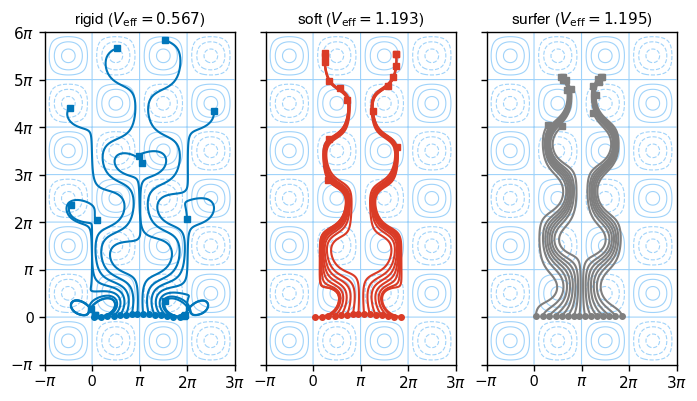

In [ ]:
def _pi_ticks(lo, hi):
    n = np.arange(int(np.floor(lo / np.pi)), int(np.ceil(hi / np.pi)) + 1)
    vals = n * np.pi
    labels = [
        "0" if k == 0 else (r"$\pi$" if k == 1 else (r"$-\pi$" if k == -1 else rf"${k}\pi$"))
        for k in n
    ]
    return vals, labels


all_y = np.concatenate([p[:, 1] for p in poss + rigid_poss + surfer_poss])
all_z = np.concatenate([p[:, 2] for p in poss + rigid_poss + surfer_poss])
Y_MIN, Y_MAX = np.floor(all_y.min() / np.pi) * np.pi, np.ceil(all_y.max() / np.pi) * np.pi
Z_MIN, Z_MAX = np.floor(all_z.min() / np.pi) * np.pi, np.ceil(all_z.max() / np.pi) * np.pi

y_tickvals, y_ticktext = _pi_ticks(Y_MIN, Y_MAX)
z_tickvals, z_ticktext = _pi_ticks(Z_MIN, Z_MAX)

# Mean vertical velocity averaged over initial positions, for each body type.
v_rigid  = float(np.mean([p[-1, 2] for p in rigid_poss]))  / float(FINAL_TIME)
v_soft   = float(np.mean([p[-1, 2] for p in poss]))        / float(FINAL_TIME)
v_surfer = float(np.mean([p[-1, 2] for p in surfer_poss])) / float(FINAL_TIME)

colors = [figstyle.COLORS["blue"], figstyle.COLORS["red"], figstyle.COLORS["grey"]]
panel_titles = (
    rf"rigid ($V_\mathrm{{eff}} = {v_rigid:.3f}$)",
    rf"soft ($V_\mathrm{{eff}} = {v_soft:.3f}$)",
    rf"surfer ($V_\mathrm{{eff}} = {v_surfer:.3f}$)",
)
trajectory_sets = (rigid_poss, poss, surfer_poss)

aspect_total = 3 * (Y_MAX - Y_MIN) / (Z_MAX - Z_MIN)
fig, axes = figstyle.subplots(size="full", aspect=aspect_total, ncols=3, sharey=True)

ny, nz = 300, 300
Y, Z = np.meshgrid(np.linspace(Y_MIN, Y_MAX, ny), np.linspace(Z_MIN, Z_MAX, nz))
PSI = 0.5 * np.sin(Y) * np.sin(Z)

for k, (ax, title, traj_set) in enumerate(
    zip(axes, panel_titles, trajectory_sets, strict=True)
):
    ax.contour(Y, Z, PSI, levels=8, colors=figstyle.COLORS["blue_25"], linewidths=0.8)
    for positions in traj_set:
        y_pos, z_pos = np.array(positions[:, 1]), np.array(positions[:, 2])
        ax.plot(y_pos, z_pos, color=colors[k], linewidth=1.5)
        ax.plot(y_pos[0], z_pos[0], marker="o", color=colors[k], markersize=4)
        ax.plot(y_pos[-1], z_pos[-1], marker="s", color=colors[k], markersize=4)
    ax.set_title(title)
    ax.set_xlim(Y_MIN, Y_MAX)
    ax.set_ylim(Z_MIN, Z_MAX)
    ax.set_aspect("equal")
    ax.set_xticks(y_tickvals, y_ticktext)
    if k == 0:
        ax.set_yticks(z_tickvals, z_ticktext)

figstyle.save(fig, "fig_soft_surfer_trajectories", figdir=FIGDIR)

## 7. Take-away

Ranking the three swimmers by their mean vertical drift, with the still-fluid swim speed $V_\mathrm{swim}=1$ as the reference:

| swimmer | $V_\mathrm{eff}/V_\mathrm{swim}$ |
|---|---|
| rigid (Pedley–Kessler baseline) | $\approx 0.567$ |
| **soft (this notebook, optimized)** | $\approx 1.193$ |
| surfer (optimal $\tau$) | $\approx 1.195$ |

A *purely passive* body with only two tunable design parameters (radius ratio and torsional spring stiffness) matches the performance of an *actively steered* surfer. The gyrotactic bias that slows the rigid body down is not eliminated but *inverted*: the soft body surfs the same flow that traps its rigid counterpart.

## References
S. Colabrese, K. Gustavsson, A. Celani, and L. Biferale, Flow navigation by smart microswimmers via reinforcement learning, *Phys. Rev. Lett.* **118**, 158004 (2017).

S. Mecanna, A. Loisy, and C. Eloy, A critical assessment of reinforcement learning methods for microswimmer navigation in complex flows, *Eur. Phys. J. E* **48**, 58 (2025).

R. Monthiller, A. Loisy, M. A. Koehl, B. Favier, and C. Eloy, Surfing on turbulence: a strategy for planktonic navigation, *Phys. Rev. Lett.* **129**, 064502 (2022).

T. Pedley and J. O. Kessler, Hydrodynamic phenomena in suspensions of swimming microorganisms, *Ann. Rev. Fluid Mech.* **24**, 313 (1992).